https://gist.github.com/resmaili/69e823d5a5bd7e0af4df7d60545dc46b

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import xarray as xr
# from google.colab import auth
from rasterio.warp import transform_bounds
from skimage.exposure import adjust_gamma, rescale_intensity

# auth.authenticate_user()

In [ ]:
# !pip install cartopy

In [2]:
def load_band(url, band_name):
  with rasterio.open(url) as src:
      data = src.read(1)
  return xr.DataArray(data, name=band_name)

In [3]:
base_url = 'https://storage.googleapis.com/gcp-public-data-landsat/LC08/01/015/033/LC08_L1TP_015033_20211105_20211116_01_T1/LC08_L1TP_015033_20211105_20211116_01_T1'

red = load_band(base_url + '_B4.TIF', 'red')
green = load_band(base_url + '_B3.TIF', 'green')
blue = load_band(base_url + '_B2.TIF', 'blue')

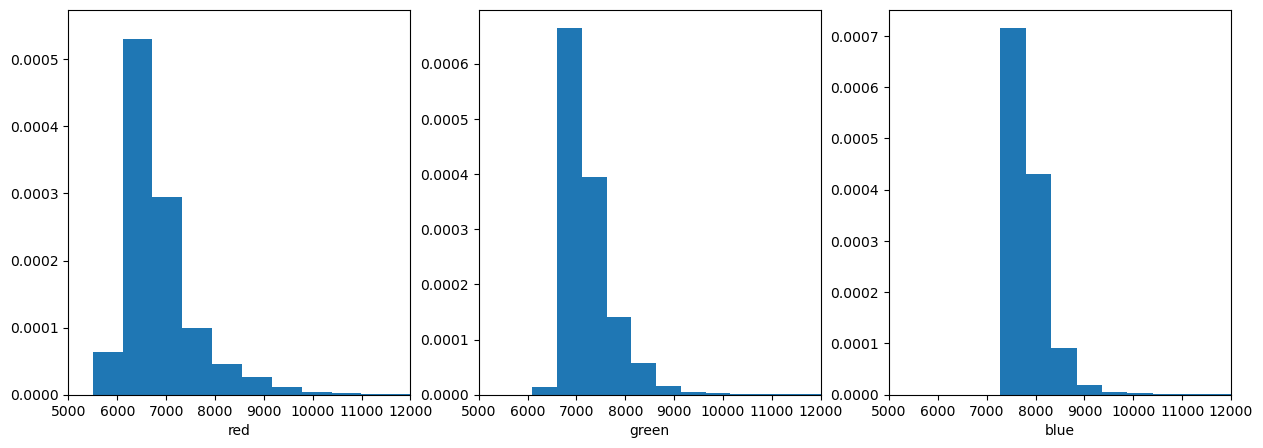

In [4]:
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
red.plot.hist(bins=100, density=True, xlim=(5000, 12000), ax=axs[0])
green.plot.hist(bins=100, density=True, xlim=(5000, 12000), ax=axs[1])
blue.plot.hist(bins=100, density=True, xlim=(5000, 12000), ax=axs[2])
plt.show()

In [5]:
red_norm = rescale_intensity(red, \
    in_range=(5500, 10000), out_range=(0, 1.0))
green_norm = rescale_intensity(green, \
    in_range=(6100, 9000), out_range=(0, 1.0))
blue_norm = rescale_intensity(blue, \
    in_range=(7250, 9000), out_range=(0, 1.0))

In [6]:
rgb_array = np.dstack([red_norm.values, green_norm.values, blue_norm.values])

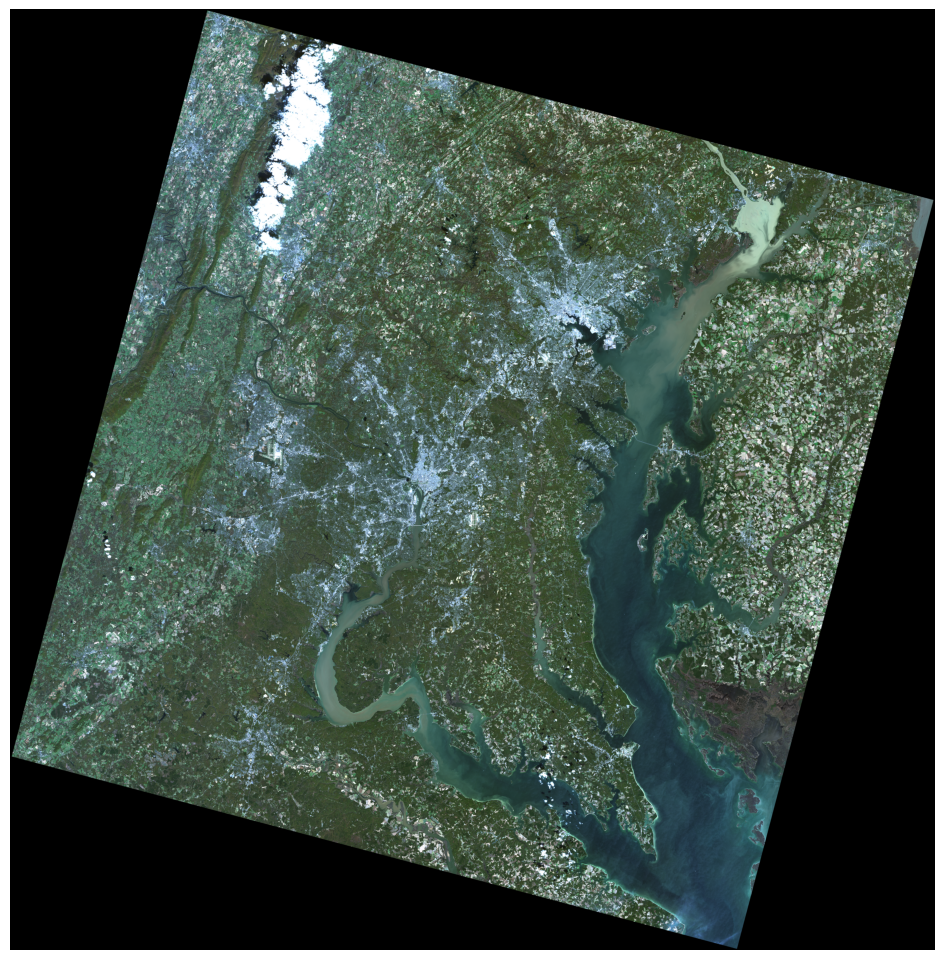

In [7]:
fig, ax = plt.subplots(figsize=[10,10])
ax.imshow(rgb_array, origin='upper', aspect='auto')
plt.tight_layout()
plt.axis('off')
plt.show()